In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
df = pd.read_csv('data_bin.csv')
print("Розмір датасету:", df.shape)
df.head()

Розмір датасету: (944, 32)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,sem,PASSED
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,4,3,4,1,1,3,4,-2.302585,True
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,5,3,3,1,1,3,2,2.208274,True
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,no,4,3,2,2,3,3,6,2.493205,True
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,3,2,2,1,1,5,0,2.646175,True
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,4,3,2,1,2,5,0,2.406945,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      944 non-null    object 
 1   sex         944 non-null    object 
 2   age         944 non-null    int64  
 3   address     944 non-null    object 
 4   famsize     944 non-null    object 
 5   Pstatus     944 non-null    object 
 6   Medu        944 non-null    int64  
 7   Fedu        944 non-null    int64  
 8   Mjob        944 non-null    object 
 9   Fjob        944 non-null    object 
 10  reason      944 non-null    object 
 11  guardian    944 non-null    object 
 12  traveltime  944 non-null    int64  
 13  studytime   944 non-null    int64  
 14  failures    944 non-null    int64  
 15  schoolsup   944 non-null    object 
 16  famsup      944 non-null    object 
 17  paid        944 non-null    object 
 18  activities  944 non-null    object 
 19  nursery     944 non-null    o

In [5]:
print("Пропущені значення:\n", df.isnull().sum())
df.describe()

Пропущені значення:
 school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
sem           0
PASSED        0
dtype: int64


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,sem
count,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000
mean,16.688559,2.636653,2.404661,1.507415,1.985169,0.253178,3.940678,3.192797,3.145127,1.475636,2.282839,3.527542,4.385593,2.284653
std,1.204638,1.129181,1.098258,0.723744,0.832653,0.645147,0.907538,1.028188,1.137949,0.877091,1.268545,1.434791,6.331564,0.679939
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,-2.302585
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,2.208274
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,2.406945
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,2.572612
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,2.949688


Розподіл PASSED:
 PASSED
True     612
False    332
Name: count, dtype: int64
Частка True: 0.648


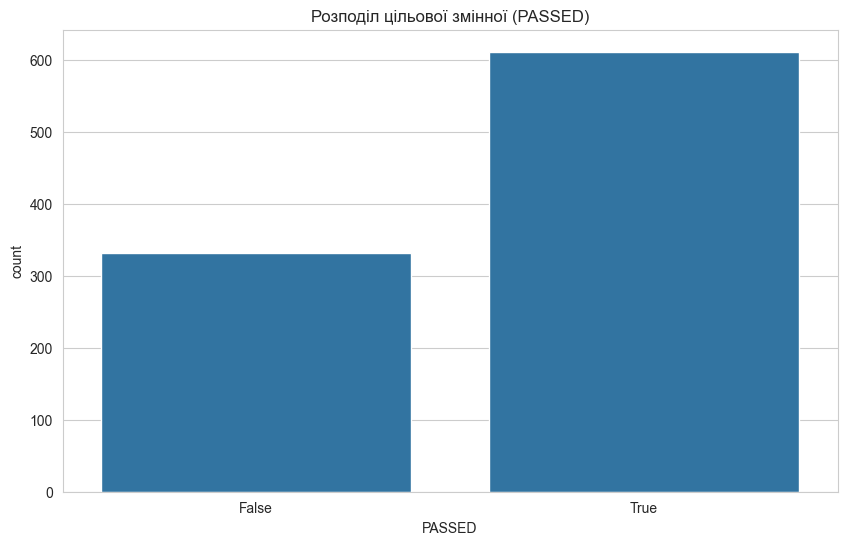

In [6]:
print("Розподіл PASSED:\n", df['PASSED'].value_counts())
print(f"Частка True: {df['PASSED'].mean():.3f}")

sns.countplot(data=df, x='PASSED')
plt.title('Розподіл цільової змінної (PASSED)')
plt.show()

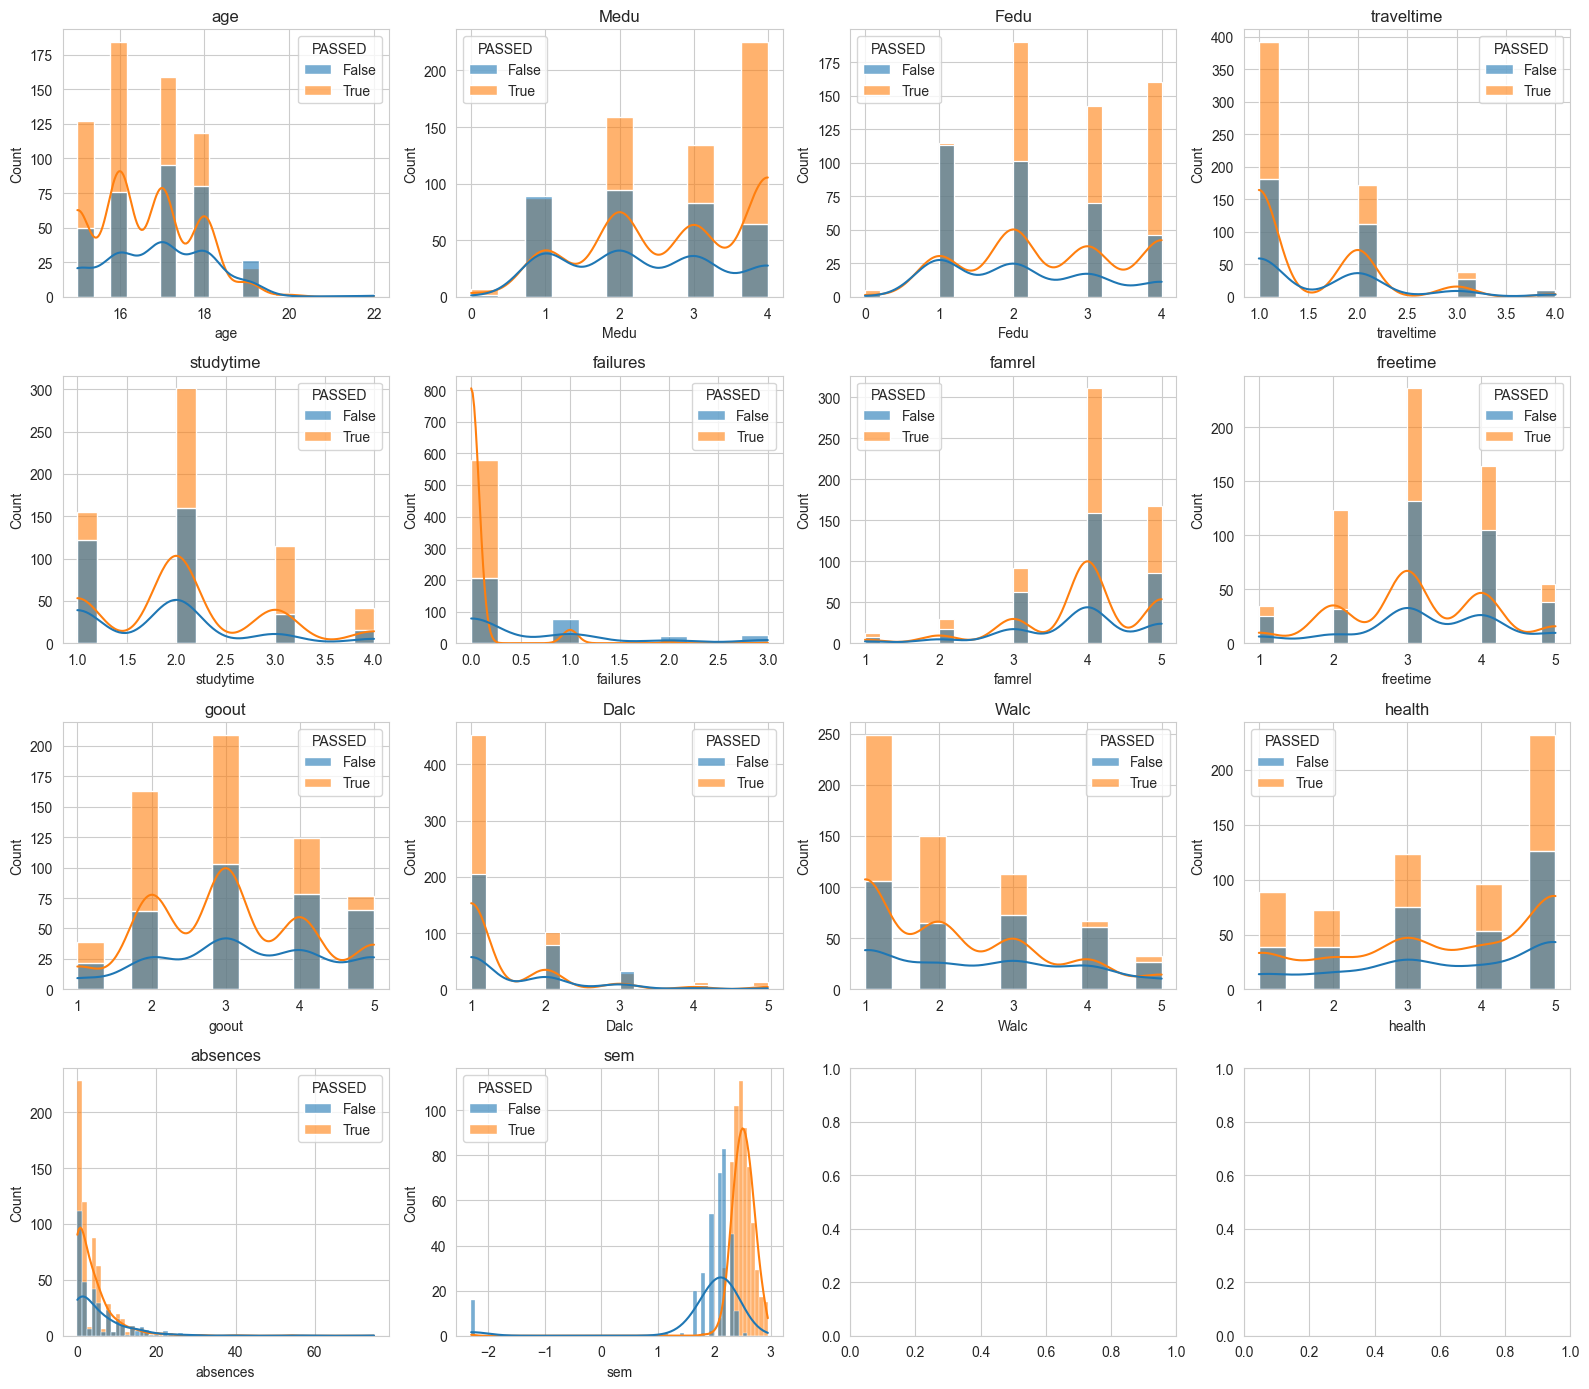

In [7]:
num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'sem']

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='PASSED', kde=True, ax=axes[i], alpha=0.6)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

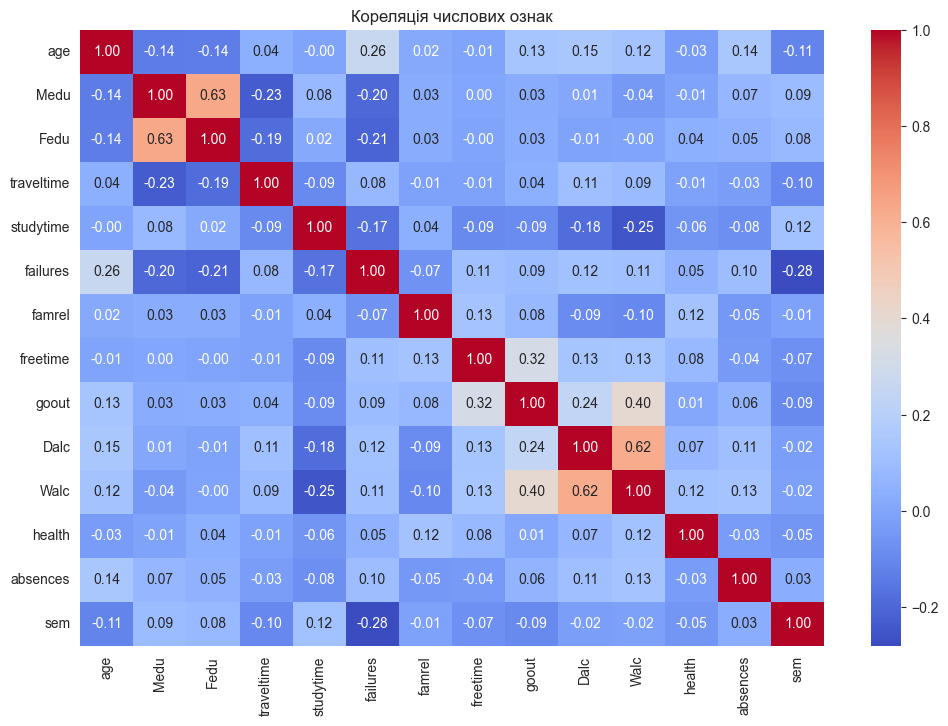

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Кореляція числових ознак')
plt.show()

In [9]:
X_num = df[num_cols].copy()
y = df['PASSED'].copy()

X_train, X_test, y_train, y_test = train_test_split(X_num, y, test_size=0.2, random_state=42, stratify=y)
print(f"Розмір тренувальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Розмір тренувальної вибірки: (755, 14)
Розмір тестової вибірки: (189, 14)


In [10]:
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['saga']
}

log_reg = LogisticRegression(random_state=42, max_iter=1000)
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Найкращі параметри:", grid_search.best_params_)
print("Найкраща середня accuracy на крос-валідації: {:.4f}".format(grid_search.best_score_))

Найкращі параметри: {'C': 10, 'penalty': 'l1', 'solver': 'saga'}
Найкраща середня accuracy на крос-валідації: 0.8715


Точність (accuracy) на тестовій вибірці: 0.8889

Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.74      0.82        66
        True       0.88      0.97      0.92       123

    accuracy                           0.89       189
   macro avg       0.90      0.85      0.87       189
weighted avg       0.89      0.89      0.89       189



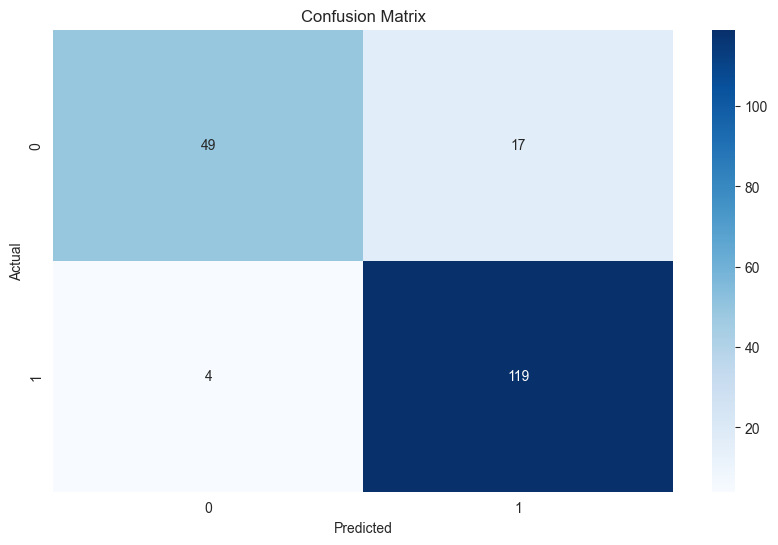

In [11]:
best_model_task2 = grid_search.best_estimator_
y_pred_task2 = best_model_task2.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred_task2)
print(f"Точність (accuracy) на тестовій вибірці: {test_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_task2))

cm = confusion_matrix(y_test, y_pred_task2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

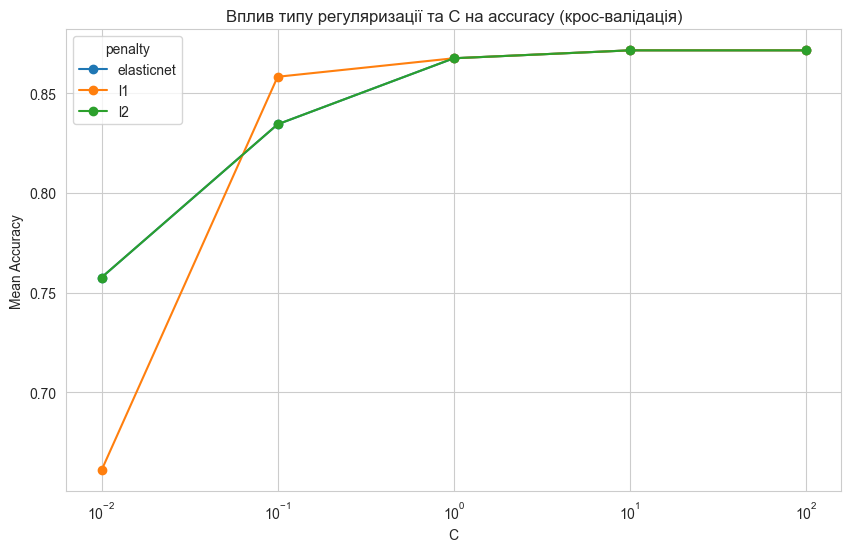

In [12]:
results = []
for penalty in ['l1', 'l2', 'elasticnet']:
    for C in [0.01, 0.1, 1, 10, 100]:
        lr = LogisticRegression(penalty=penalty, C=C, solver='saga', random_state=42, max_iter=1000)
        scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='accuracy')
        results.append({'penalty': penalty, 'C': C, 'mean_accuracy': scores.mean(), 'std_accuracy': scores.std()})

results_df = pd.DataFrame(results)
pivot = results_df.pivot(index='C', columns='penalty', values='mean_accuracy')
pivot.plot(marker='o')
plt.title('Вплив типу регуляризації та C на accuracy (крос-валідація)')
plt.xlabel('C')
plt.ylabel('Mean Accuracy')
plt.xscale('log')
plt.show()

In [13]:
categorical_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 
                    'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 
                    'nursery', 'higher', 'internet', 'romantic']
all_features = [col for col in df.columns if col != 'PASSED']
num_cols_full = [col for col in all_features if col not in categorical_cols]

print("Числові ознаки:", num_cols_full)
print("Категоріальні ознаки:", categorical_cols)

X = df.drop('PASSED', axis=1)
y = df['PASSED']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Числові ознаки: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'sem']
Категоріальні ознаки: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_full),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ])

def evaluate_model(model, param_grid, model_name):
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)
    print(f"\n=== {model_name} ===")
    print("Найкращі параметри:", grid.best_params_)
    print("Найкраща accuracy на CV: {:.4f}".format(grid.best_score_))
    
    y_pred = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    
    print(f"Тестова accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"AUC-ROC: {roc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    return grid, y_pred, y_proba

In [15]:
param_grid_lr = {
    'classifier__penalty': ['l1', 'l2', 'elasticnet'],
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__l1_ratio': [0.15, 0.5, 0.85]
}

lr_model = LogisticRegression(solver='saga', random_state=42, max_iter=1000)
grid_lr, y_pred_lr, y_proba_lr = evaluate_model(lr_model, param_grid_lr, "LogisticRegression(saga)")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

=== LogisticRegression(saga) ===
Найкращі параметри: {'classifier__C': 1, 'classifier__l1_ratio': 0.15, 'classifier__penalty': 'l1'}
Найкраща accuracy на CV: 0.8649
Тестова accuracy: 0.8783
Precision: 0.8623
Recall: 0.9675
F1-score: 0.9119
AUC-ROC: 0.9618

Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.71      0.80        66
        True       0.86      0.97      0.91       123

    accuracy                           0.88       189
   macro avg       0.89      0.84      0.86       189
weighted avg       0.88      0.88      0.87       189



In [16]:
param_grid_sgd = {
    'classifier__penalty': ['l1', 'l2', 'elasticnet'],
    'classifier__alpha': [0.0001, 0.001, 0.01, 0.1],
    'classifier__l1_ratio': [0.15, 0.5, 0.85],
    'classifier__max_iter': [1000, 2000],
    'classifier__learning_rate': ['optimal', 'adaptive']
}

sgd_model = SGDClassifier(loss='log_loss', random_state=42, early_stopping=False, tol=1e-3)
grid_sgd, y_pred_sgd, y_proba_sgd = evaluate_model(sgd_model, param_grid_sgd, "SGDClassifier(log_loss)")

Fitting 5 folds for each of 144 candidates, totalling 720 fits

=== SGDClassifier(log_loss) ===
Найкращі параметри: {'classifier__alpha': 0.01, 'classifier__l1_ratio': 0.15, 'classifier__learning_rate': 'optimal', 'classifier__max_iter': 1000, 'classifier__penalty': 'l1'}
Найкраща accuracy на CV: 0.8728
Тестова accuracy: 0.9101
Precision: 0.9015
Recall: 0.9675
F1-score: 0.9333
AUC-ROC: 0.9643

Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.80      0.86        66
        True       0.90      0.97      0.93       123

    accuracy                           0.91       189
   macro avg       0.92      0.89      0.90       189
weighted avg       0.91      0.91      0.91       189



In [17]:
best_lr_auc = roc_auc_score(y_test, y_proba_lr)
best_sgd_auc = roc_auc_score(y_test, y_proba_sgd)
print(f"AUC-ROC для LogisticRegression: {best_lr_auc:.4f}")
print(f"AUC-ROC для SGDClassifier: {best_sgd_auc:.4f}")

if best_lr_auc >= best_sgd_auc:
    best_model = grid_lr.best_estimator_
    best_proba = y_proba_lr
    best_pred = y_pred_lr
    best_name = "LogisticRegression(saga)"
else:
    best_model = grid_sgd.best_estimator_
    best_proba = y_proba_sgd
    best_pred = y_pred_sgd
    best_name = "SGDClassifier(log_loss)"

print(f"\nНайкраща модель: {best_name}")
print(f"AUC-ROC = {max(best_lr_auc, best_sgd_auc):.4f}")

AUC-ROC для LogisticRegression: 0.9618
AUC-ROC для SGDClassifier: 0.9643

Найкраща модель: SGDClassifier(log_loss)
AUC-ROC = 0.9643


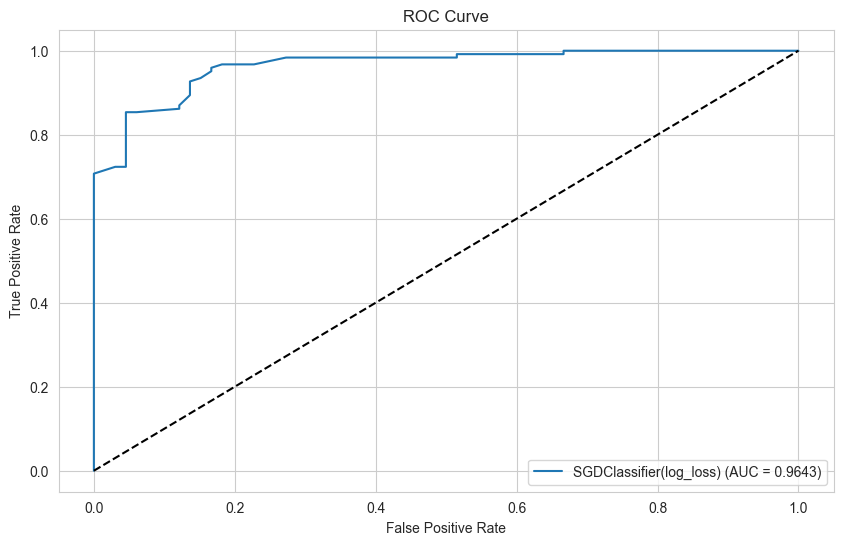

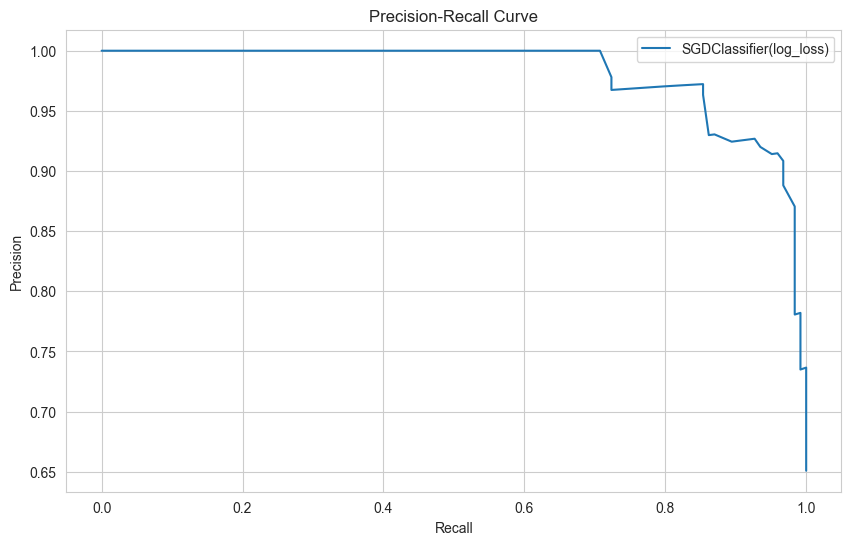

In [18]:
fpr, tpr, _ = roc_curve(y_test, best_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'{best_name} (AUC = {roc_auc_score(y_test, best_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

precision, recall, _ = precision_recall_curve(y_test, best_proba)
plt.figure()
plt.plot(recall, precision, label=f'{best_name}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [19]:
predict_df = pd.read_csv('predict.csv')
print("Розмір predict.csv:", predict_df.shape)
predict_df.head()

Розмір predict.csv: (100, 31)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,sem
0,MS,M,16,U,GT3,T,1,1,at_home,services,...,no,yes,5,4,5,4,5,3,0,-2.302585
1,MS,F,17,U,GT3,T,1,1,other,at_home,...,no,no,4,3,2,1,2,5,9,1.960095
2,GP,F,18,U,LE3,T,2,2,at_home,services,...,yes,yes,5,3,1,1,1,5,16,2.091864
3,MS,F,18,U,GT3,T,2,2,other,other,...,yes,yes,1,3,1,1,1,2,4,2.091864
4,MS,M,17,U,GT3,T,1,2,other,other,...,yes,yes,5,3,5,5,5,1,12,1.808289


In [20]:
missing_cols = set(X_train.columns) - set(predict_df.columns)
if missing_cols:
    print("Увага! У predict.csv відсутні колонки:", missing_cols)
else:
    print("Всі ознаки наявні.")

best_clf_model_predictions = best_model.predict(predict_df)
best_clf_model_predict_proba = best_model.predict_proba(predict_df)

print("\nПерші 10 прогнозів:")
for i in range(10):
    print(best_clf_model_predictions[i], best_clf_model_predict_proba[i, 1])

Всі ознаки наявні.

Перші 10 прогнозів:
False 9.118293385586883e-24
False 0.03754499364957375
False 0.1201569305539417
False 0.1917367914928468
False 0.0029239959367003683
True 0.990419321721545
True 0.7195585046466251
True 0.8848719996485161
True 0.9919935039591974
False 0.001394156424181756


In [21]:
output_df = pd.DataFrame({
    'preds': best_clf_model_predictions,
    'probas': best_clf_model_predict_proba[:, 1]
})
output_df.to_csv('predictions_clf.csv', index=False)
print("Файл predictions_clf.csv збережено.")

Файл predictions_clf.csv збережено.


=== Порівняння моделей ===
Метрика         Тільки числові       Усі ознаки (краща)  
-------------------------------------------------------
Accuracy        0.8519               0.9101              
Precision       0.8322               0.9015              
Recall          0.9675               0.9675              
F1-score        0.8947               0.9333              
AUC-ROC         0.9422               0.9643              


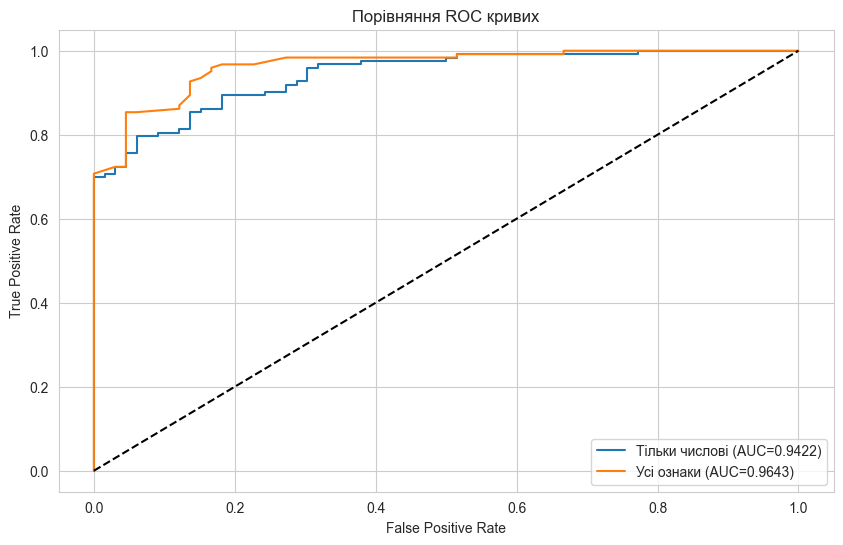

In [22]:
pipeline_num = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l2', C=0.1, solver='saga', random_state=42, max_iter=1000))
])
pipeline_num.fit(X_train[num_cols], y_train)
y_pred_num = pipeline_num.predict(X_test[num_cols])
y_proba_num = pipeline_num.predict_proba(X_test[num_cols])[:, 1]

print("=== Порівняння моделей ===")
print(f"{'Метрика':<15} {'Тільки числові':<20} {'Усі ознаки (краща)':<20}")
print("-" * 55)
print(f"{'Accuracy':<15} {accuracy_score(y_test, y_pred_num):<20.4f} {accuracy_score(y_test, best_pred):<20.4f}")
print(f"{'Precision':<15} {precision_score(y_test, y_pred_num):<20.4f} {precision_score(y_test, best_pred):<20.4f}")
print(f"{'Recall':<15} {recall_score(y_test, y_pred_num):<20.4f} {recall_score(y_test, best_pred):<20.4f}")
print(f"{'F1-score':<15} {f1_score(y_test, y_pred_num):<20.4f} {f1_score(y_test, best_pred):<20.4f}")
print(f"{'AUC-ROC':<15} {roc_auc_score(y_test, y_proba_num):<20.4f} {roc_auc_score(y_test, best_proba):<20.4f}")

fpr_num, tpr_num, _ = roc_curve(y_test, y_proba_num)
plt.figure()
plt.plot(fpr_num, tpr_num, label=f'Тільки числові (AUC={roc_auc_score(y_test, y_proba_num):.4f})')
plt.plot(fpr, tpr, label=f'Усі ознаки (AUC={roc_auc_score(y_test, best_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Порівняння ROC кривих')
plt.legend()
plt.show()